# Order Book Imbalance (*for MSFT*)
### The notebook orchastrates: load -> compute -> label -> analyse -> plot

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lobster_loader import load_lobster_day, add_mid_price
from obi import add_obi_columns
from data_labels import add_forward_returns

# Load Data
msg_path = "data/MSFT_2012-06-21_34200000_57600000_message_10.csv"
book_path = "data/MSFT_2012-06-21_34200000_57600000_orderbook_10.csv"

df = load_lobster_day(msg_path, book_path, n_levels=10)
df = add_mid_price(df)
df = add_obi_columns(df, depths=[1, 5, 10])

df[['time', 'mid_price', 'obi_depth1', 'obi_depth5', 'obi_depth10']].head(10)

# Label
labeled = add_forward_returns(df, horizons=[1, 5, 30, 100])

## Why Microsoft (*MSFT*) has stronger correlation than Apple (*APPL*)

Investigated whether book depth explains - MSFT has stronger OBI-Correlation returns than AAPL.
Depth was ruled out because in both share-count and dollar depth, MSFT is actually deeper than AAPL, which rules out thinner book theory.

Actual driver was **relative tick size**: MSFT trades at ~$30, while AAPL at ~$580. This means $0.01 tick is ~19x larger than MSFT's price.
This makes MSFT's price grid coarser -- AAPL's best ask changes 32,999 times in a day (with 1,062 unique prices) while MSFT's change 3,258 times (with 109 uniqu prices) and MSFT also shows multi-minute quiet stretches (82 gaps 60 seconds, max gap - 207 seconds), these never occur in AAPL.

A coarser, stickier price grid gives more order flow more time to build at a given level before price move, which lets obi reflect real buy/sell pressure, ahead of the move.

Confirmed this is a genuine market microstructure effect and not a labelling artifact: forward returns (`data_labels.py`) are computed in calander time via merge_asof, so the horizon means the same real world time gap for both stocks despite different row counts.

### Correlation Test

In [2]:
from scipy.stats import spearmanr

obi_cols = ['obi_depth1', 'obi_depth5', 'obi_depth10']
ret_cols = ['fwd_returns_1s', 'fwd_returns_5s', 'fwd_returns_30s', 'fwd_returns_100s']

corr_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)
pval_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)

before = len(df) 
df = add_forward_returns(df, [1, 5, 30, 100])
df_clean = df.dropna(subset=obi_cols+ret_cols) # drop rows with NaN values

after = len(df_clean)
print(f"before: {before}, after: {after}, dropped: {before-after} ({100*(before-after)/before:.1f}%)")

for obi_col in obi_cols:
    for ret_col in ret_cols:
        corr, pval = spearmanr(df_clean[obi_col], df_clean[ret_col])
        corr_table.loc[obi_col, ret_col] = corr
        pval_table.loc[obi_col, ret_col] = pval

print(corr_table)
print()
print(pval_table)

before: 668765, after: 661065, dropped: 7700 (1.2%)
             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1         0.398076        0.366511         0.192929          0.079959
obi_depth5         0.275022        0.243839         0.099264         -0.004347
obi_depth10        0.187015        0.167209         0.109564          0.056970

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1              0.0             0.0              0.0          0.000000
obi_depth5              0.0             0.0              0.0          0.000409
obi_depth10             0.0             0.0              0.0          0.000000


### Plot

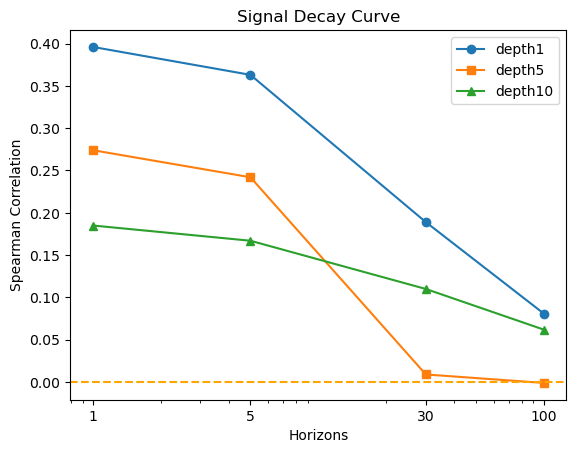

In [3]:
horizons = [1, 5, 30, 100]
corr_depth1 = [0.396, 0.363, 0.189, 0.081]
corr_depth5 = [0.274, 0.242, 0.009, -0.001]
corr_depth10 = [0.185, 0.167, 0.110, 0.062]

plt.plot(horizons, corr_depth1, marker='o', label='depth1')
plt.plot(horizons, corr_depth5, marker='s', label='depth5')
plt.plot(horizons, corr_depth10, marker='^', label='depth10')

plt.xscale('log')

plt.axhline(0, color='orange', linestyle='--')
plt.xlabel('Horizons')
plt.ylabel('Spearman Correlation')
plt.title('Signal Decay Curve')
plt.legend()
plt.xticks(horizons, [str(h) for h in horizons])

plt.show()

### Pre-Registered Significance Threshold + Bonferroni Correlation

In [4]:
# number_of_thresholds = 12
new_threshold = 0.05/12
print(new_threshold)

0.004166666666666667


In [5]:
"""
we would call a test significant if p-value < 0.00416
                                    else -> not significant
"""
from scipy.stats import spearmanr

obi_cols = ['obi_depth1', 'obi_depth5', 'obi_depth10']
ret_cols = ['fwd_returns_1s', 'fwd_returns_5s', 'fwd_returns_30s', 'fwd_returns_100s']

corr_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)
pval_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)

before = len(df) 
df = add_forward_returns(df, [1, 5, 30, 100])
df_clean = df.dropna(subset=obi_cols+ret_cols) # drop rows with NaN values

after = len(df_clean)
print(f"before: {before}, after: {after}, dropped: {before-after} ({100*(before-after)/before:.1f}%)")

for obi_col in obi_cols:
    for ret_col in ret_cols:
        corr, pval = spearmanr(df_clean[obi_col], df_clean[ret_col])
        corr_table.loc[obi_col, ret_col] = corr
        pval_table.loc[obi_col, ret_col] = pval

print()
print(corr_table)
print()
print(pval_table)
print()
sig_table = pval_table < new_threshold
print(sig_table)

before: 668765, after: 661065, dropped: 7700 (1.2%)

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1         0.398155        0.366536         0.192944          0.079969
obi_depth5         0.275085        0.243965         0.099265         -0.004332
obi_depth10        0.186889        0.167634         0.109553          0.057042

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1              0.0             0.0              0.0          0.000000
obi_depth5              0.0             0.0              0.0          0.000428
obi_depth10             0.0             0.0              0.0          0.000000

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1             True            True             True              True
obi_depth5             True            True             True              True
obi_depth10            True            True             True              Tr